# Grupp projekt i Unsupervised machine learning 27.04.2026 

- Välj ett valfritt dataset
- Rengör data 
- Utför EDA, beskriv data och relationer mellan variabler
- Utför Unsupervised machine learning, minst en teknik

•Presentation: 

- Beskriv datasetet, variabler, relationer mellan variabler. 
- Presentera resultat av Unsupervised machine learning, beskriv vad ni hittade.
- Presentera resultat som databerättelse (runt 15 min). 
- Hur tolkar ni resultat? Vilken värde har det för t.ex. affärsverksamhet?

Gör en story.

EXTRA om ni vill: 
- Gör statistik på era klustrar, jämför variabler, visualisera
- Testa algoritmer som vi gick inte genom: DBSCAN, K-prototypes, One-Class SVM, eller Local Outlier Factor etc, beroende på data och frågor ni ställer till data. 
- Beskriv vad detta algoritm gör och varför ni har valt just den (leka med data är en bra orsak också!).

# 1. Introduktion

## Kundsegmentering inom detaljhandel med PCA och K-Means

### Syfte
Syftet med projektet är att analysera kunders köpbeteende och identifiera olika kundgrupper med hjälp av Unsupervised Machine Learning. Genom segmentering kan företag förbättra marknadsföring, kundlojalitet och försäljning.

### Frågeställning
Kan vi identifiera tydliga kundsegment baserat på köpdata, och hur kan dessa segment skapa affärsvärde?

In [1]:
# Importera bibliotek

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

# Ladda dataset
df = pd.read_csv("/Users/victoria/Documents/aikurs/04_UnsupervisedML/data/online_retail.csv")

# 2. Initial dataöversikt

## Dataset
Vi använder Online Retail Dataset, som innehåller transaktionsdata från en nätbutik.

541 909 rader i det orensade datasetet

## Variabler i datasetet:
- InvoiceNo    541909 non-null  str    
- StockCode    541909 non-null  str    
- Description  540455 non-null  str    
- Quantity     541909 non-null  int64  
- InvoiceDate  541909 non-null  str    
- UnitPrice    541909 non-null  float64
- CustomerID   406829 non-null  float64
- Country      541909 non-null  str 

In [2]:
# Inspektera datasetet
print(df.head())
print(df.info())
print(df.describe())
df.duplicated().sum()
print("Tomma strängar:")
empty_strings = (df == '').sum()
print(empty_strings)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   ----- 

# 3. Datarengöring

### Skapa kopia av originaldata

### Kontroll av saknade värden
En kontroll av saknade värden visade att framför allt variabeln CustomerID innehöll ett stort antal tomma värden.
- CustomerID (135 080) -> observationer utan CustomerID togs bort eftersom de saknar unik kundidentifiering
- Description (1 454) -> ersatt nollvärden med "None"

### Dubbletter
- 5 268 rader innehöll exakt samma information i samtliga variabler. Dessa bedömdes vara dubbletter och togs bort.

### Tomma stränger
- En kontroll genomfördes för tomma textfält. Inga tomma strängar identifierades efter att saknade värden i varibeln Description hade ersatts med "None".

### Inkonsekventa format
- Fakturadatum (InvoiceDate) var fel formaterade: str -> datetime
- KundID (CustomerID) var fel formaterade: float -> int
- Kvantitet (Quantity) var fel formaterade: float -> int

### Felaktiga värden 
- Ta bort returer-annullerade köp: Inga negativa värden återstod i varbeln Quantity vide denna kontroll. Detta indikerar att observationer med negativa kvantiteter redan hade exkluderats i tidigare datarengöringssteg, exempelvis vid borttagning av annullerade köp och returer.
- Ta bort ogiltiga numeriska värden (negativ kvantitet eller pris)

In [3]:
# Skapa kopia av originaldata
df_clean = df.copy()

# Kontroll av saknade värden
print("Antal saknade värden:") 
print(df_clean.isnull().sum())

# Ersatt nollvärden i Description med "None"
df_clean["Description"] = df["Description"].fillna("None")

# Ta bort saknade CustID
df_clean = df_clean.dropna(subset=["CustomerID"])
print("\nAntal saknade värden efter datarengörning:")
print(df_clean.isnull().sum())

# Ta bort dubbletter
print("\nDubbleter: ", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Dubbleter efter rensning: ", df_clean.duplicated().sum())

# Tomma stränger
print("\nAntal tomma stränger i datasetet:", (df_clean == "").sum().sum())

# Inkonsekventa format
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

# Felaktiga värden 

# Ta bort returer-annullerade köp
print("\nAntal annullerade köp: ", df_clean["InvoiceNo"].astype(str).str.startswith("C").sum())
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]
print("Antal annullerade köp i det rensade datasetet: ", df_clean["InvoiceNo"].astype(str).str.startswith("C").sum())

# Ta bort ogiltiga numeriska värden (negativ kvantitet eller pris)
print("\nAntal rader med Quantity <= 0: ", (df_clean["Quantity"] <= 0).sum())
print("Antal rader med UnitPrice <= 0: ", (df_clean["UnitPrice"] <= 0).sum())
df_clean = df_clean[df_clean["UnitPrice"] > 0]
print("Antal rader med UnitPrice <= 0 i det rensade datasetet: ", (df_clean["UnitPrice"] <= 0).sum())

# Skapa omsättning (Revenue)
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Export av rensad data
df_clean.to_csv("/Users/victoria/Documents/aikurs/04_UnsupervisedML/data/online_retail_cleaned.csv", index=False)

Antal saknade värden:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Antal saknade värden efter datarengörning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Dubbleter:  5225
Dubbleter efter rensning:  0

Antal tomma stränger i datasetet: 0

Antal annullerade köp:  8872
Antal annullerade köp i det rensade datasetet:  0

Antal rader med Quantity <= 0:  0
Antal rader med UnitPrice <= 0:  40
Antal rader med UnitPrice <= 0 i det rensade datasetet:  0


# 4. Explorativ dataanalys (EDA)

## Översikt efter datarengöring
Efter datarengöring återstod 392 692 transaktionsrader i datasetet. Dessa representerade 4 338 unika kunder fördelade över 37 länder. Datamängden innehöll information om fakturanummer, produkter, antal köpta enheter, köpdatum, pris och omsättning. Datasetet omfattade perioden 1 december 2010 till 9 december 2011. Den stora variationen i köpstorlek och omsättning indikerar att kundbeteendet skiljer sig mellan kunder, vilket motiverar vidare segmenteringsanalys. Datasetet omfattar transaktioner från 1 december 2010 till 9 december 2011.

In [4]:
# Översikt efter datarengöring
print(df_clean.info())
print(df_clean.describe())
print(df_clean.head())

print("\nAntal rader:", len(df_clean))
print("Antal kunder: ", df_clean["CustomerID"].nunique())
print("Antal länder: ", df_clean["Country"].nunique())

print("Första fakturadatum:", df_clean["InvoiceDate"].min())
print("Sista fakturadatum:", df_clean["InvoiceDate"].max())

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  str           
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  str           
 8   Revenue      392692 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 30.0 MB
None
            Quantity                 InvoiceDate      UnitPrice  \
count  392692.000000                      392692  392692.000000   
mean       13.119702  2011-07-10 19:13:07.771892       3.125914   
min         1.000000         2010-12-01 08:26:00       0.001000   
25%  

## Tidsmönster i försäljningen

Diagrammet visar att den totala omsättningen varierade mellan månaderna. Efter en relativt stabil nivå under årets första del ökade försäljningen tydligt under hösten, med topp i november. Detta kan indikera säsongseffekter, exempelvis ökad handel inför årets slut.

Den låga omsättningen i december 2011 bör tolkas med försiktighet eftersom datasetet endast innehåller transaktioner till och med den 9 december. Nedgången speglar därför sannolikt ofullständig data snarare än faktisk minskad efterfrågan.

Month
2010-12    570422.730
2011-01    568101.310
2011-02    446084.920
2011-03    594081.760
2011-04    468374.331
Freq: M, Name: Revenue, dtype: float64


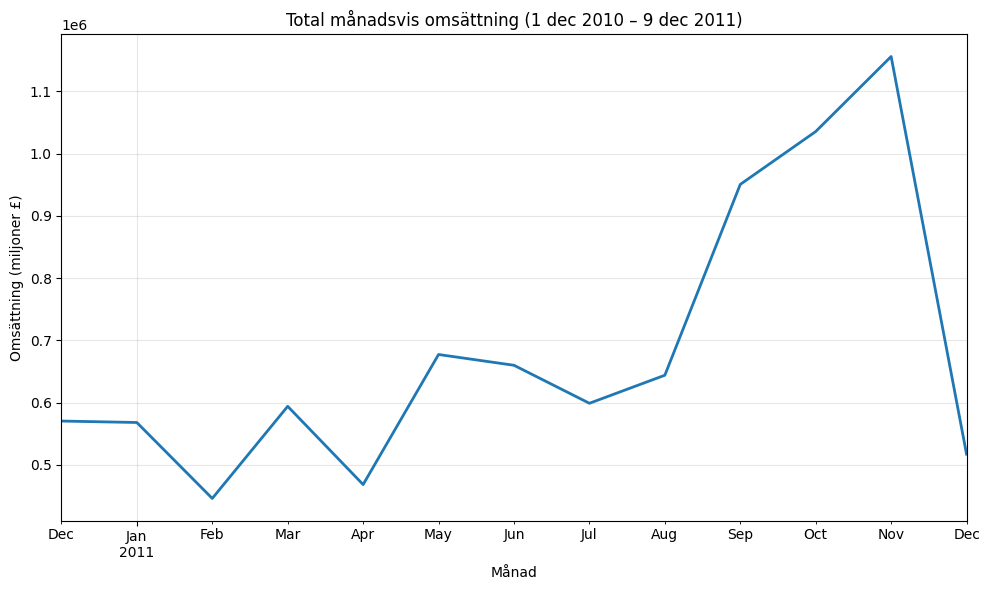

Omsättning första 9 dagarna i december 2011: 517190.44
Uppskattad total omsättning för december 2011: 1781433.7377777777


In [5]:
# Försäljning över tid
df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M")

monthly_sales = df_clean.groupby("Month")["Revenue"].sum()
print(monthly_sales.head())


ax = monthly_sales.plot(
    figsize=(10,6),
    linewidth=2
)

plt.title("Total månadsvis omsättning (1 dec 2010 – 9 dec 2011)")
plt.xlabel("Månad")
plt.ylabel("Omsättning (miljoner £)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Filtrera fram alla transaktioner från December 2011
dec_2011 = df_clean[(df_clean["InvoiceDate"].dt.year == 2011) & (df_clean["InvoiceDate"].dt.month == 12)]

# Beräkna total omsättning för de första 9 dagarna som finns i datasetet
partial_revenue = dec_2011["Revenue"].sum()

# Uppskatta hel månads omsättning genom att räkna ut dagsgenomsnitt och multiplicera med decembers 31 dagar
estimated_full = (partial_revenue / 9) * 31

# Skriv ut resultatet
print("Omsättning första 9 dagarna i december 2011:", partial_revenue)
print("Uppskattad total omsättning för december 2011:", estimated_full)

## Mest sålda produkter
Diagrammet visar de tio mest sålda produkterna baserat på antal enheter. Försäljningen var koncentrerad till ett mindre antal populära produkter, där PAPER CRAFT , LITTLE BIRDIE hade högst volym. Detta indikerar tydliga skillnader i efterfrågan mellan olika produkter och kan vara värdefullt för lagerplanering, kampanjer och sortimentsbeslut.

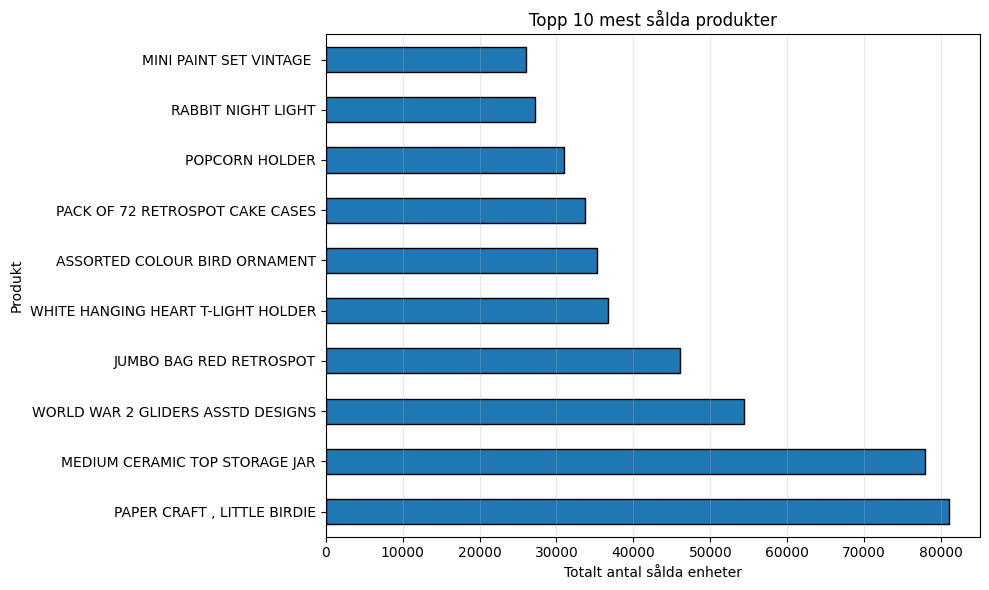

In [6]:
# Mest sålda produkter
top_products = (
    df_clean.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

ax = top_products.plot(
    kind="barh",
    figsize=(10,6),
    edgecolor="black"
)

plt.title("Topp 10 mest sålda produkter")
plt.xlabel("Totalt antal sålda enheter")
plt.ylabel("Produkt")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## Geografiska skillnader
Diagrammet visar att omsättningen var starkt koncentrerad till United Kingdom, som tydligt dominerade försäljningen jämfört med övriga länder. Detta indikerar att företagets hemmamarknad stod för den största delen av intäkterna. Bland övriga marknader återfanns bland annat Netherlands, EIRE, Germany och France, men på betydligt lägre nivåer. Totalt omfattade datasetet 37 länder, vilket visar att verksamheten hade internationell räckvidd trots den tydliga dominansen från Storbritannien.

Storbrittanien dominerade den totala omsättning tack vare ett mycket stort antal transaktioner, men återfanns inte bland de högsta länderna sett till genomsnittlig omsättning per transaktion. Detta tyder på att den brittiska marknade kännetecknas av hög volym snarare än höga genomsnittliga ordervärden.

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Finland',
              'Austria',               'Greece',            'Singapore',
              'Lebanon', 'United Arab Emirates',               'Israel',
         'Saudi Arabia',       'Czech Republic',               'Canada',
          'Unspecified',               'Brazil',                  'USA',
   'European Community',              'Bahrain',                'Malta',
                  'RSA']
Length: 37, dtype: str


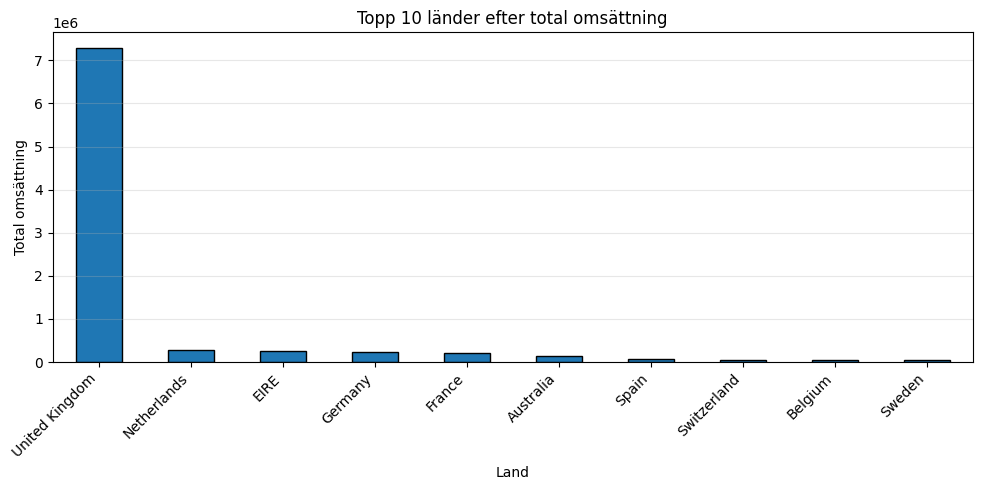

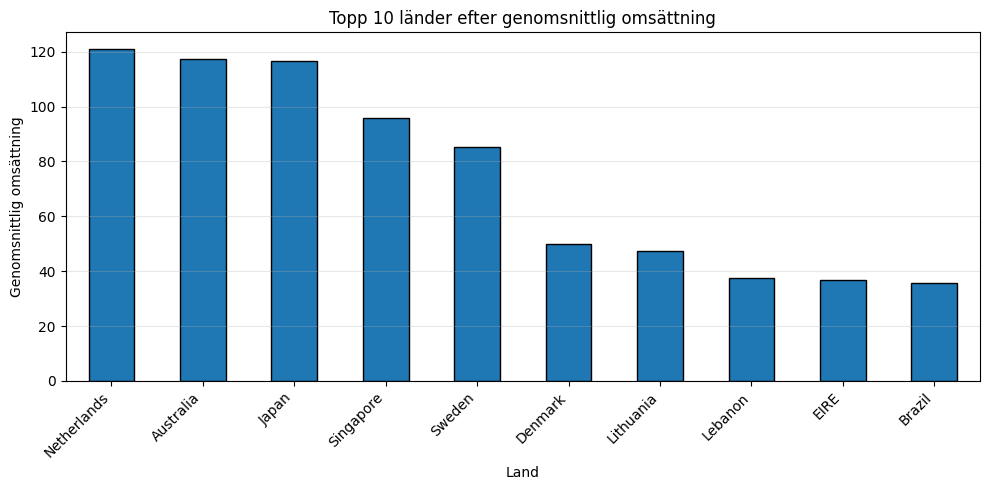

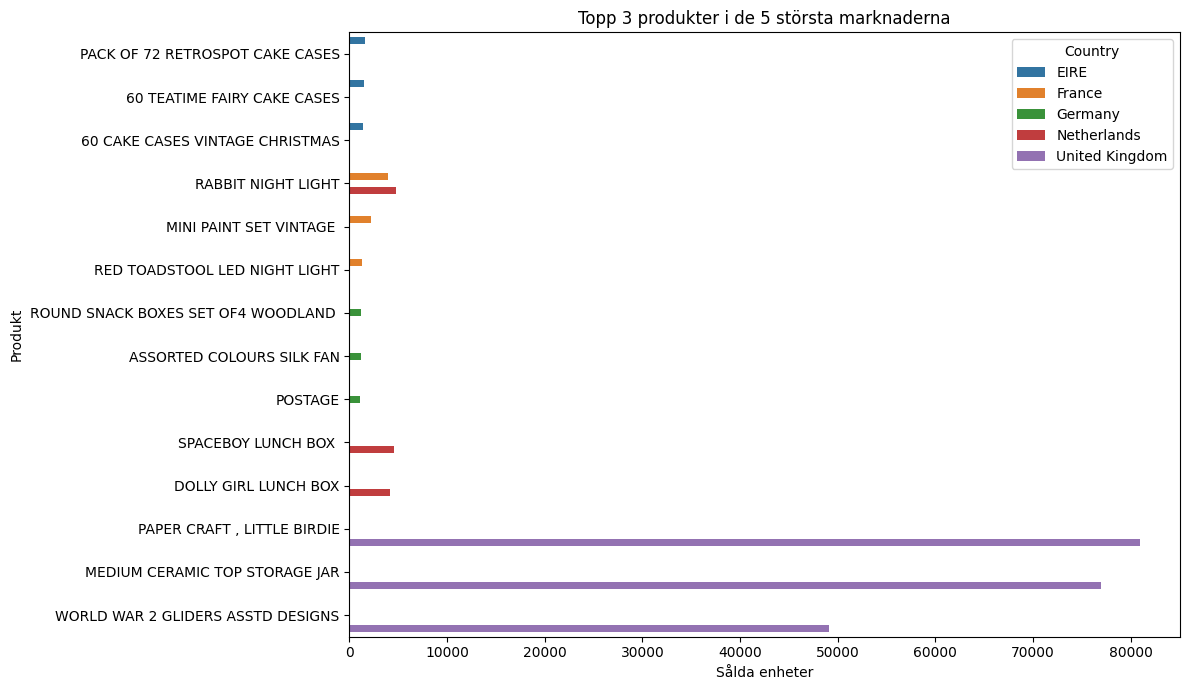

In [7]:
# Försäljning per land
print(df_clean["Country"].unique())

country_sales = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

ax = country_sales.plot(
    kind="bar",
    figsize=(10,5),
    edgecolor="black"
)

plt.title("Topp 10 länder efter total omsättning")
plt.xlabel("Land")
plt.ylabel("Total omsättning")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

avg_country = df_clean.groupby("Country")["Revenue"].mean().sort_values(ascending=False).head(10)

ax = avg_country.plot(kind="bar", figsize=(10,5), edgecolor="black")

plt.title("Topp 10 länder efter genomsnittlig omsättning")
plt.xlabel("Land")
plt.ylabel("Genomsnittlig omsättning")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Top 5 countries by revenue
top_countries = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# Filter those countries
filtered = df_clean[df_clean["Country"].isin(top_countries)]

# Top 3 products per country
top_products_country = (
    filtered.groupby(["Country", "Description"])["Quantity"]
    .sum()
    .reset_index()
)

top3 = (
    top_products_country
    .sort_values(["Country", "Quantity"], ascending=[True, False])
    .groupby("Country")
    .head(3)
)

# visualisation

plt.figure(figsize=(12,7))

sns.barplot(
    data=top3,
    x="Quantity",
    y="Description",
    hue="Country"
)

plt.title("Topp 3 produkter i de 5 största marknaderna")
plt.xlabel("Sålda enheter")
plt.ylabel("Produkt")
plt.tight_layout()
plt.show()

## Kundbeteende
Totalt identifierades 4 338 unika kunder. Medianen var 2 ordrar per kund, vilket innebär att hälften av kunderna genomförde två eller färre köp. Samtidigt var medelvärdet 4,27 ordrar, vilket är högre än medianen och visar att ett mindre antal kunder handlade betydligt oftare än genomsnittet. Den vanligaste kundtypen var kunder som endast genomförde en order, medan maxvärdet uppgick till 209 ordrar. Detta bekräftar stora skillnader i köpfrekvens mellan kunderna och att fördelningen är tydligt högerskev.

Boxploten visar dessutom flera extrema observationer, där ett mindre antal kunder genomförde mycket fler köp än majoriteten. Histogrammet över log-transformerad total omsättning per kund visar att kundernas värde varierade kraftigt, men att de flesta kunder låg inom ett mer koncentrerat mellanintervall medan ett fåtal kunder stod för mycket hög omsättning.

Spridningsdiagrammet visar även ett övergripande positivt samband mellan antal ordrar och total omsättning. Kunder som handlar oftare tenderar generellt att generera högre intäkter. Samtidigt finns tydlig variation, där vissa kunder handlar sällan men spenderar mycket, medan andra handlar ofta med lägre ordervärden. Detta tyder på flera olika kundtyper och motiverar vidare segmentering.

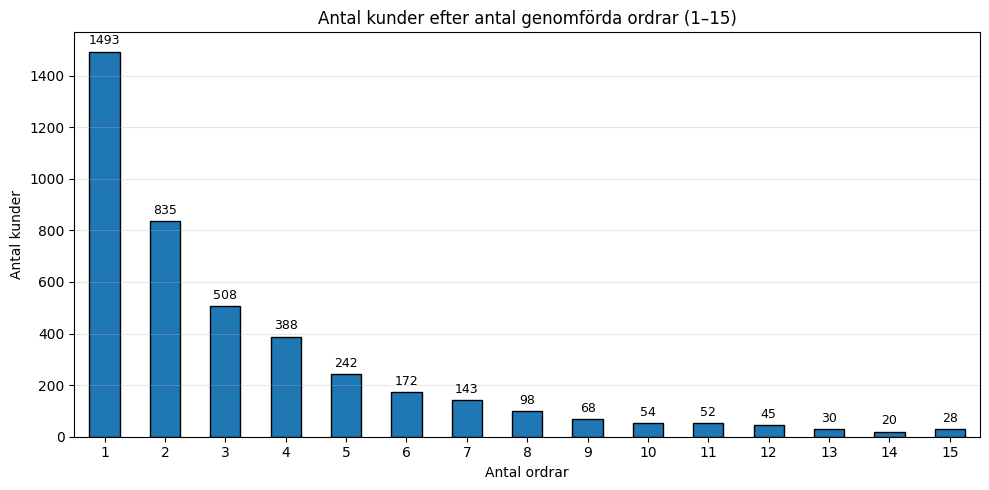

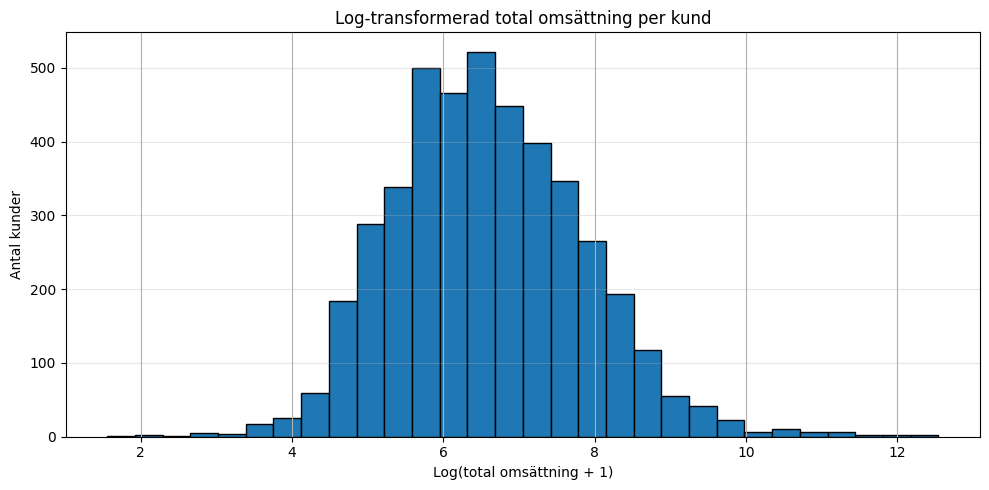

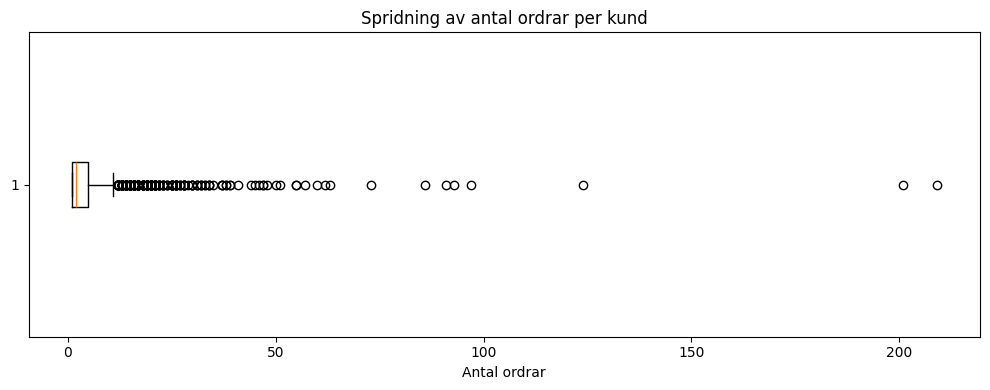

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64


In [8]:
# Kundbeteende
orders = df_clean.groupby("CustomerID")["InvoiceNo"].nunique()
order_counts = orders.value_counts().sort_index()

ax = order_counts[order_counts.index <= 15].plot(
    kind="bar",
    figsize=(10,5),
    edgecolor="black"
)

plt.title("Antal kunder efter antal genomförda ordrar (1–15)")
plt.xlabel("Antal ordrar")
plt.ylabel("Antal kunder")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

# Lägg till värden ovanför varje stapel
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{int(height)}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

# Spending per customer
spend = df_clean.groupby("CustomerID")["Revenue"].sum()
np.log1p(spend).hist(bins=30, edgecolor="black", figsize=(10,5))
plt.title("Log-transformerad total omsättning per kund")
plt.xlabel("Log(total omsättning + 1)")
plt.ylabel("Antal kunder")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Boxplot ordrar
plt.figure(figsize=(10,4))
plt.boxplot(orders, vert=False)

plt.title("Spridning av antal ordrar per kund")
plt.xlabel("Antal ordrar")
plt.tight_layout()
plt.show()

print(orders.describe())

## Relationer mellan variabler
Korrelationsanalysen visar ett starkt positivt samband mellan Quantity och Revenue (0,91), vilket är naturligt eftersom omsättningen påverkas direkt av antal sålda enheter. Sambandet mellan UnitPrice och Revenue var däremot svagt positivt, vilket indikerar att prisnivån ensam hade mindre påverkan på omsättningen än köpt volym. Mellan Quantity och UnitPrice observerades i princip inget linjärt samband.

Spridningsdiagrammet mellan antal ordrar per kund och total omsättning visar samtidigt ett övergripande positivt samband på kundnivå. Kunder som genomförde fler köp tenderade generellt att generera högre intäkter. Samtidigt framgår tydlig variation, där vissa kunder handlade få gånger men spenderade mycket, medan andra handlade ofta med lägre ordervärden.

Resultatet tyder på att både köpfrekvens och kundvärde varierar mellan kunder, vilket stärker motivet för vidare kundsegmentering med klustringsmetoder.

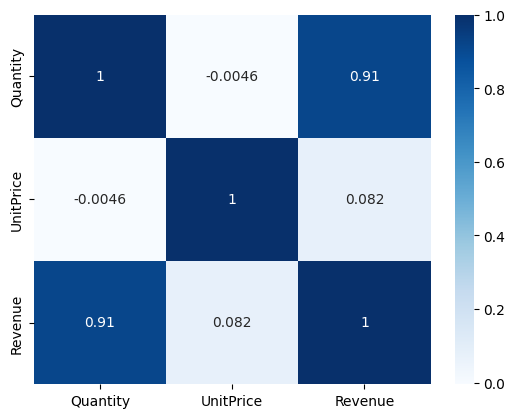

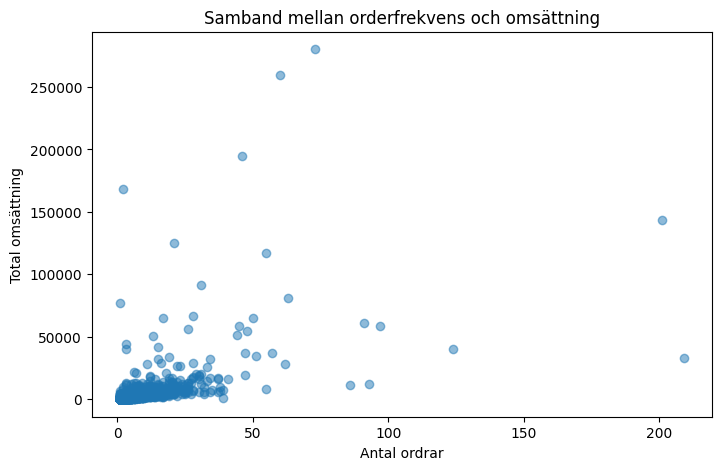

In [9]:
# Samband mellan variabler
df_clean[["Quantity","UnitPrice","Revenue"]].corr()

sns.heatmap(df_clean[["Quantity","UnitPrice","Revenue"]].corr(), annot=True, cmap="Blues")


# Orders vs Revenue
customer_df = df_clean.groupby("CustomerID").agg({
    "InvoiceNo":"nunique",
    "Revenue":"sum"
})

customer_df.columns = ["Orders", "Revenue"]

plt.figure(figsize=(8,5))
plt.scatter(customer_df["Orders"], customer_df["Revenue"], alpha=0.5)
plt.xlabel("Antal ordrar")
plt.ylabel("Total omsättning")
plt.title("Samband mellan orderfrekvens och omsättning")
plt.show()

## Sammanfattning av insikter
Den explorativa dataanalysen visar att kundbeteendet varierade tydligt mellan både kunder, produkter och marknader. Försäljningen var starkt koncentrerad till United Kingdom, medan flera internationella marknader uppvisade lägre total volym men i vissa fall högre genomsnittliga ordervärden.

Kundanalysen visade att majoriteten av kunderna genomförde få köp, medan ett mindre antal kunder stod för mycket hög köpfrekvens och hög omsättning. Det fanns även kunder som handlade sällan men spenderade stora belopp per köp, vilket tyder på olika typer av kundvärde.

Försäljningen varierade dessutom över tid, med en tydlig ökning under hösten och topp i november, vilket indikerar säsongseffekter. Produktanalysen visade samtidigt att en mindre grupp produkter stod för en stor del av försäljningsvolymen.

Sammantaget visar resultaten att kundbasen är heterogen och innehåller flera olika beteendemönster. Detta skapar goda förutsättningar för vidare kundsegmentering med hjälp av unsupervised machine learning, exempelvis PCA och K-Means.

# 5. Feature engineering

- Recency / Senaste köp
- Frequency / Köpfrekvens
- Monetary / Total omsättning
- AveOrderValue / Genomsnittligt ordervärde
- UniqueProducts / Antal unika produkter

## Recency / Senaste köp
Variabeln **Recency** skapades för att mäta antal dagar sedan kundens senaste köp. Referensdatum sattes till dagen efter den sista registerade transaktionen i datasetet. Lägre värden indikerar nyligen aktiva kunder, medan högre värden indikerar kunder som inte har handlat på längre tid.

   CustomerID  Recency
0       12346      326
1       12347        2
2       12348       75
3       12349       19
4       12350      310
5       12352       36
6       12353      204
7       12354      232
8       12355      214
9       12356       23
         CustomerID      Recency
count   4338.000000  4338.000000
mean   15300.408022    92.536422
std     1721.808492   100.014169
min    12346.000000     1.000000
25%    13813.250000    18.000000
50%    15299.500000    51.000000
75%    16778.750000   142.000000
max    18287.000000   374.000000


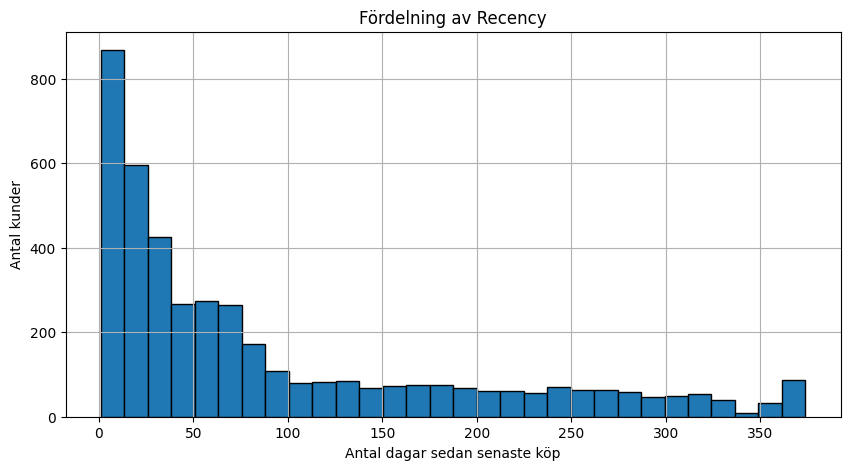

In [10]:
# Välj referensdatum
snapshot_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

# Beräkna Recency per kund
recency = df_clean.groupby("CustomerID")["InvoiceDate"].max().reset_index()

recency["Recency"] = (
    snapshot_date - recency["InvoiceDate"]
).dt.days

# Behåll relevanta kolumner
recency = recency[["CustomerID", "Recency"]]

# Visa resultat
print(recency.head(10))
print(recency.describe())

recency["Recency"].hist(bins=30, edgecolor="black", figsize=(10,5))

plt.title("Fördelning av Recency")
plt.xlabel("Antal dagar sedan senaste köp")
plt.ylabel("Antal kunder")
plt.show()

## Frequency / Köpfrekvens
**Frequency** visar hur många unika ordrar varje kund har genomfört under den analyserade perioden. Variabeln används för att mäta hur aktiv och återkommande kunden är. Ett högre värde innebär att kunden handlar oftare, medan ett lägre värde innebär färre köp.

Frequency beräknas utifrån antal unika ordernummer (**InvoiceNo**) och inte antal rader i datasetet. Detta är viktigt eftersom en order kan innehålla flera produkter och därmed flera transaktionsrader. Genom att använda unika ordernummer erhålls därför ett mer rättvisande mått på kundens faktiska köpbeteende.

Histogrammet visar att majoriteten av kunderna genomförde ett lågt antal ordrar, medan ett mindre antal kunder handlade betydligt oftare. Fördelningen bedöms vara tydligt högerskev, vilket indikerar stora skillnader i kundernas aktivitetsnivå och motiverar vidare kundsegmentering.


   CustomerID  Frequency
0       12346          1
1       12347          7
2       12348          4
3       12349          1
4       12350          1
5       12352          8
6       12353          1
7       12354          1
8       12355          1
9       12356          3
         CustomerID    Frequency
count   4338.000000  4338.000000
mean   15300.408022     4.272015
std     1721.808492     7.697998
min    12346.000000     1.000000
25%    13813.250000     1.000000
50%    15299.500000     2.000000
75%    16778.750000     5.000000
max    18287.000000   209.000000


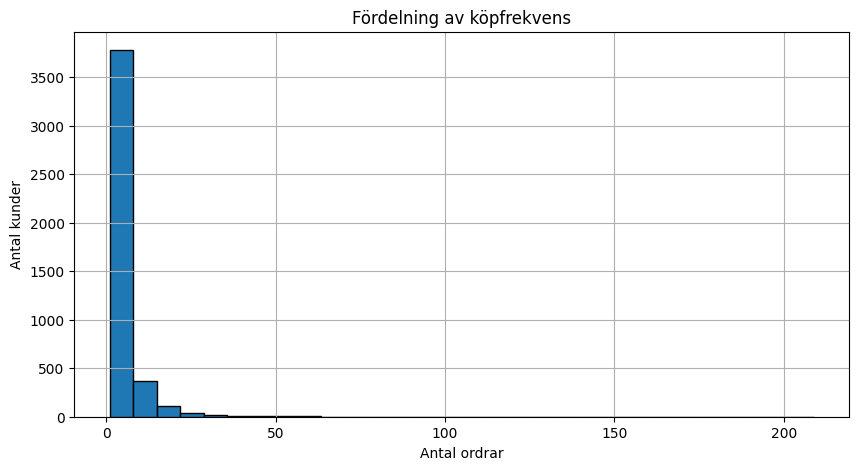

In [11]:
# Beräkna antal unika ordrar per kund
frequency = df_clean.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()

# Byt kolumnnamn
frequency.columns = ["CustomerID", "Frequency"]

# Visa resultat
print(frequency.head(10))
print(frequency.describe())

frequency["Frequency"].hist(bins=30, edgecolor="black", figsize=(10,5))

plt.title("Fördelning av köpfrekvens")
plt.xlabel("Antal ordrar")
plt.ylabel("Antal kunder")
plt.show()

## Monetary / Total omsättning
**Monetary** visar kundens totala omsättning under den analyserade perioden och används för att mäta kundens ekonomiska värde. Ett högre värde innebär att kunden har spenderat mer totalt, medan ett lägre värde innebär lägre total konsumtion.

Monetary beräknas genom att summera variabeln Revenue för varje kund, där Revenue tidigare definierats som Quantity × UnitPrice.

Histogrammet visar att majoriteten av kunderna hade relativt låg total omsättning, medan ett mindre antal kunder stod för mycket höga belopp. Fördelningen är därför tydligt högerskev.

För att ge en tydligare bild av variationen visas även en log-transformerad version av variabeln. Efter transformationen framträder en mer balanserad fördelning, vilket gör variabeln mer lämplig för vidare analys med PCA och klustring.

Monetary är särskilt relevant vid kundsegmentering eftersom variabeln kan användas för att identifiera kunder med olika ekonomiskt värde.

   CustomerID  Monetary
0       12346  77183.60
1       12347   4310.00
2       12348   1797.24
3       12349   1757.55
4       12350    334.40
5       12352   2506.04
6       12353     89.00
7       12354   1079.40
8       12355    459.40
9       12356   2811.43
         CustomerID       Monetary
count   4338.000000    4338.000000
mean   15300.408022    2048.688081
std     1721.808492    8985.230220
min    12346.000000       3.750000
25%    13813.250000     306.482500
50%    15299.500000     668.570000
75%    16778.750000    1660.597500
max    18287.000000  280206.020000


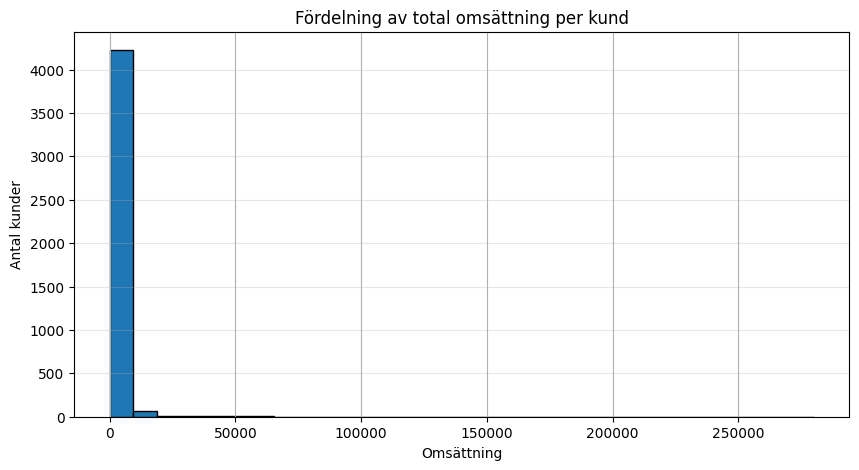

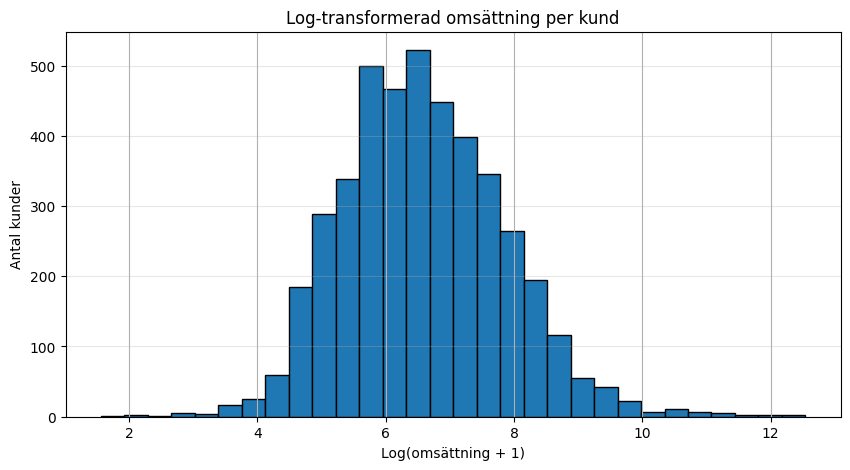

In [12]:
# Beräkna total omsättning per kund
monetary = df_clean.groupby("CustomerID")["Revenue"].sum().reset_index()

# Byt kolumnnamn
monetary.columns = ["CustomerID", "Monetary"]

# Visa resultat
print(monetary.head(10))
print(monetary.describe())

# Visualisering
monetary["Monetary"].hist(bins=30, edgecolor="black", figsize=(10,5))

plt.title("Fördelning av total omsättning per kund")
plt.xlabel("Omsättning")
plt.ylabel("Antal kunder")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Log-transformerad version (lättare att tolka)
np.log1p(monetary["Monetary"]).hist(bins=30, edgecolor="black", figsize=(10,5))

plt.title("Log-transformerad omsättning per kund")
plt.xlabel("Log(omsättning + 1)")
plt.ylabel("Antal kunder")
plt.grid(axis="y", alpha=0.3)
plt.show()

## AvgOrderValue / Genomsnittligt ordervärde

**AvgOrderValue** visar hur mycket kunden i genomsnitt spenderar per order. Variabeln används för att skilja mellan kunder som handlar ofta med mindre köp och kunder som gör färre men större köp.

AvgOrderValue beräknas genom att dividera kundens totala omsättning (**Monetary**) med antal ordrar (**Frequency**).

Histogrammet visar att majoriteten av kunderna hade låga till medelhöga ordervärden, medan ett mindre antal kunder hade betydligt högre nivåer. Fördelningen är därför tydligt **högerskev**.

Medianvärdet var cirka **292**, medan medelvärdet var cirka **418**, vilket visar påverkan från högre extremvärden. Den högsta observerade nivån var **84 236**.

En **log-transformerad** version visar en mer balanserad fördelning och gör variabeln mer lämplig för vidare analys med PCA och klustring.

AvgOrderValue är relevant vid kundsegmentering eftersom variabeln skiljer mellan kunder med många små köp och kunder med färre men större köp.


   CustomerID  AvgOrderValue
0       12346   77183.600000
1       12347     615.714286
2       12348     449.310000
3       12349    1757.550000
4       12350     334.400000
5       12352     313.255000
6       12353      89.000000
7       12354    1079.400000
8       12355     459.400000
9       12356     937.143333
         CustomerID  AvgOrderValue
count   4338.000000    4338.000000
mean   15300.408022     417.645735
std     1721.808492    1796.511343
min    12346.000000       3.450000
25%    13813.250000     177.867083
50%    15299.500000     291.940000
75%    16778.750000     428.280625
max    18287.000000   84236.250000


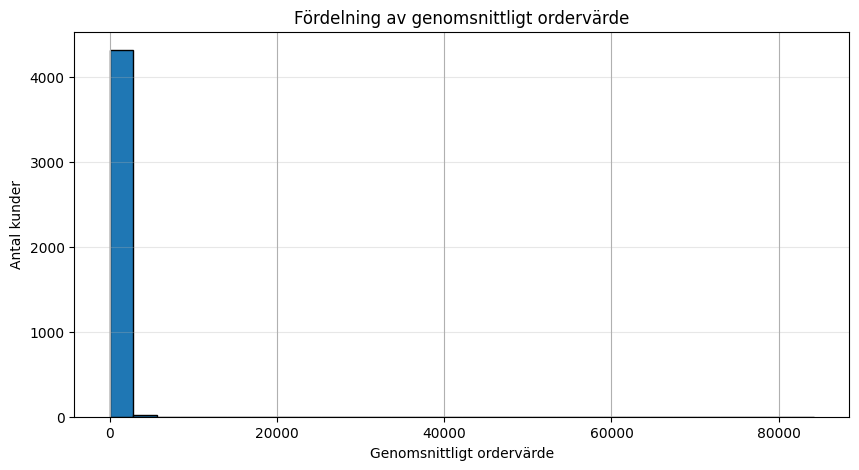

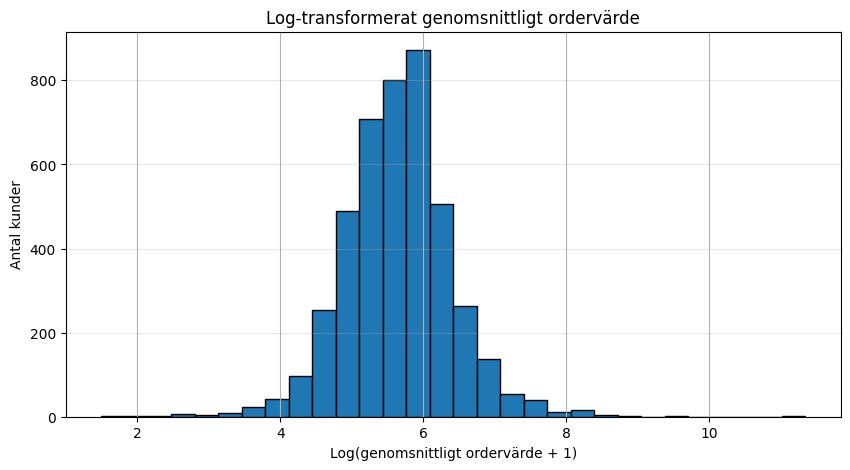

In [13]:
# Slå ihop Frequency och Monetary via CustomerID
avg_order = frequency.merge(monetary, on="CustomerID")

# Beräkna genomsnittligt ordervärde
avg_order["AvgOrderValue"] = (
    avg_order["Monetary"] / avg_order["Frequency"]
)

# Behåll relevanta kolumner
avg_order = avg_order[["CustomerID", "AvgOrderValue"]]

# Visa resultat
print(avg_order.head(10))
print(avg_order.describe())

# Visualiseringar
avg_order["AvgOrderValue"].hist(
    bins=30,
    edgecolor="black",
    figsize=(10,5)
)

plt.title("Fördelning av genomsnittligt ordervärde")
plt.xlabel("Genomsnittligt ordervärde")
plt.ylabel("Antal kunder")
plt.grid(axis="y", alpha=0.3)
plt.show()

np.log1p(avg_order["AvgOrderValue"]).hist(
    bins=30,
    edgecolor="black",
    figsize=(10,5)
)

plt.title("Log-transformerat genomsnittligt ordervärde")
plt.xlabel("Log(genomsnittligt ordervärde + 1)")
plt.ylabel("Antal kunder")
plt.grid(axis="y", alpha=0.3)
plt.show()

## UniqueProducts / Antal unika produkter

**UniqueProducts** visar hur många olika produkter varje kund har köpt under den analyserade perioden och används för att mäta hur varierat kundens köpbeteende är.

Variabeln beräknas genom att räkna antal unika produktkoder (**StockCode**) per kund. Ett högre värde innebär att kunden köpt många olika produkter, medan ett lägre värde tyder på ett mer begränsat köpmönster.

Histogrammet visar att majoriteten av kunderna köpte ett relativt lågt antal olika produkter, medan ett mindre antal kunder hade betydligt högre värden. Fördelningen är därför tydligt **högerskev**.

Medianvärdet var **35** produkter och medelvärdet cirka **61,5**, vilket visar påverkan från högre extremvärden. Den högsta observerade nivån var **1 787** produkter.

En **log-transformerad** version ger en mer balanserad fördelning och gör variabeln mer lämplig för vidare analys med PCA och klustring.


   CustomerID  UniqueProducts
0       12346               1
1       12347             103
2       12348              22
3       12349              73
4       12350              17
5       12352              59
6       12353               4
7       12354              58
8       12355              13
9       12356              53
         CustomerID  UniqueProducts
count   4338.000000     4338.000000
mean   15300.408022       61.501153
std     1721.808492       85.366768
min    12346.000000        1.000000
25%    13813.250000       16.000000
50%    15299.500000       35.000000
75%    16778.750000       77.000000
max    18287.000000     1787.000000


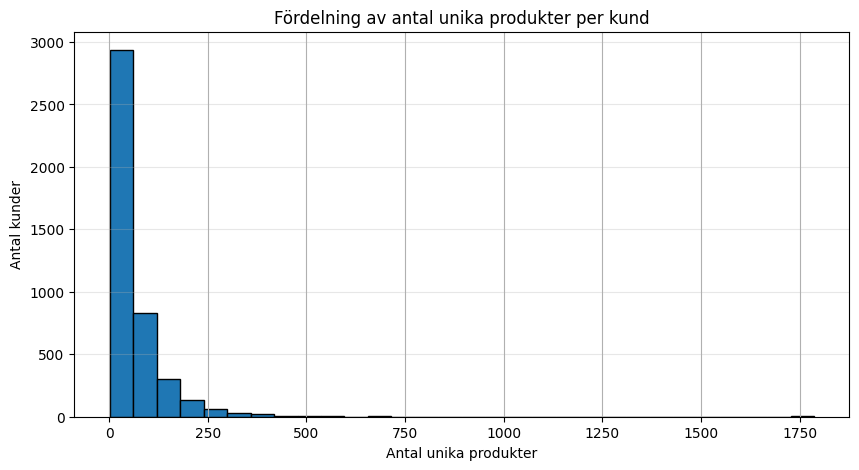

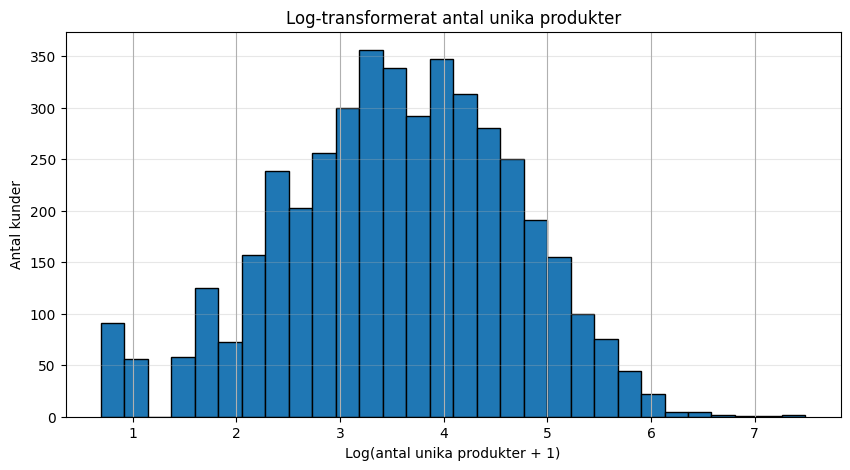

In [14]:
# Beräkna antal unika produkter per kund
unique_products = df_clean.groupby("CustomerID")["StockCode"].nunique().reset_index()

# Byt kolumnnamn
unique_products.columns = ["CustomerID", "UniqueProducts"]

# Visa resultat
print(unique_products.head(10))
print(unique_products.describe())

# Histogram
unique_products["UniqueProducts"].hist(
    bins=30,
    edgecolor="black",
    figsize=(10,5)
)

plt.title("Fördelning av antal unika produkter per kund")
plt.xlabel("Antal unika produkter")
plt.ylabel("Antal kunder")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Log-transformerad version
np.log1p(unique_products["UniqueProducts"]).hist(
    bins=30,
    edgecolor="black",
    figsize=(10,5)
)

plt.title("Log-transformerat antal unika produkter")
plt.xlabel("Log(antal unika produkter + 1)")
plt.ylabel("Antal kunder")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Samband mellan skapade variabler
**Korrelationsmatrisen** visar samband mellan de skapade kundvariablerna. Särskilt tydliga positiva samband kan observeras mellan Frequency, Monetary och UniqueProducts, vilket indikerar att kunder som handlar ofta även tenderar att spendera mer och köpa fler olika produkter. Recency uppvisar negativa samband med aktivitetsvariablerna, vilket är logiskt då lägre recency innebär mer nyligen aktiv kund.

   CustomerID  Recency  Frequency  Monetary  AvgOrderValue  UniqueProducts
0       12346      326          1  77183.60   77183.600000               1
1       12347        2          7   4310.00     615.714286             103
2       12348       75          4   1797.24     449.310000              22
3       12349       19          1   1757.55    1757.550000              73
4       12350      310          1    334.40     334.400000              17


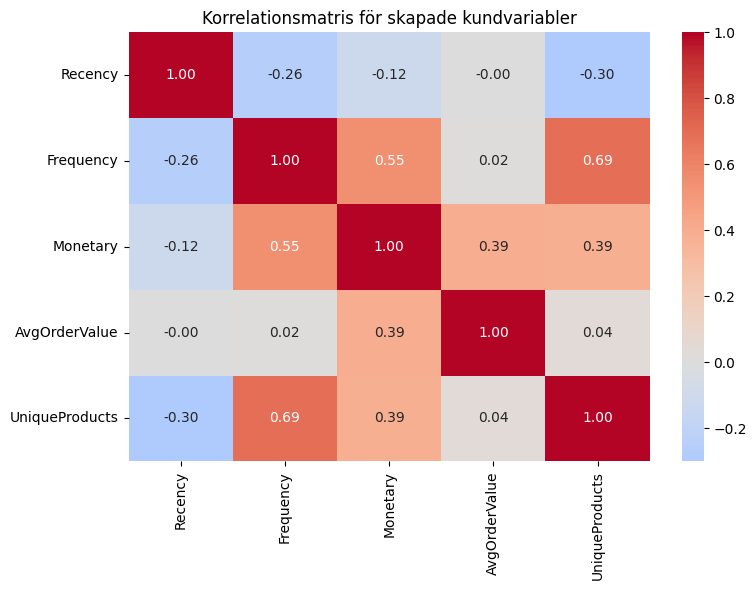

In [15]:
customer_features = recency.merge(frequency, on="CustomerID") \
                           .merge(monetary, on="CustomerID") \
                           .merge(avg_order, on="CustomerID") \
                           .merge(unique_products, on="CustomerID")

print(customer_features.head())

plt.figure(figsize=(8,6))

sns.heatmap(
    customer_features.drop("CustomerID", axis=1).corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Korrelationsmatris för skapade kundvariabler")
plt.tight_layout()
plt.show()

# 6. Förbehandling inför modellering

Efter feature engineering bestod datamängden av flera kundbaserade variabler som beskriver olika aspekter av köpbeteende. Innan PCA och klustring genomfördes behövde datan förberedas för modellering.

Syftet med förbehandlingen var att sammanställa samtliga variabler i en gemensam kundtabell, kontrollera datakvaliteten samt anpassa variablernas skala och fördelning. Detta är särskilt viktigt eftersom metoder som **PCA** och **K-Means** är känsliga för skillnader i skala och extremvärden.

I detta steg genomfördes därför sammanslagning av features, kontroll av saknade värden, log-transformering av skeva variabler samt standardisering av datan inför den fortsatta analysen.


## Kontrollera saknade värden

In [16]:
print("Saknade värden: ", customer_features.isnull().sum())

Saknade värden:  CustomerID        0
Recency           0
Frequency         0
Monetary          0
AvgOrderValue     0
UniqueProducts    0
dtype: int64


## Hantera skevhet

In [17]:
cols = ["Frequency","Monetary","AvgOrderValue","UniqueProducts"]

for col in cols:
    customer_features[col] = np.log1p(customer_features[col])

## Skalning
Recency behölls i ursprunglig skala (antal dagar), medan övriga starkt högerskeva variabler log-transformerades för att minska effekten av extrema värden. Därefter standardiserades samtliga analysvariabler med StandardScaler för att säkerställa jämförbara skalor inför PCA och klustring. CustomerID exkluderades från analysen eftersom variabeln endast fungerar som identifierare.

In [18]:
X = customer_features.drop("CustomerID", axis=1)

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# 7. PCA
PCA (Principal Component Analysis) användes för att reducera antalet dimensioner i kunddatan och sammanfatta informationen i färre variabler, så kallade huvudkomponenter. Metoden kombinerar de ursprungliga variablerna till nya komponenter som fångar största möjliga variation i datan.

Analysen genomfördes efter standardisering av variablerna eftersom PCA är känslig för skillnader i skala mellan features. De fem kundvariablerna reducerades till två huvudkomponenter (PC1 och PC2) för att möjliggöra visualisering samt underlätta fortsatt klustringsanalys.

Scree ploten visade att den första komponenten förklarade 60,5 % av variationen och den andra 19,7 %. Tillsammans förklarade de två första komponenterna 80,3 % av den totala variationen, vilket bedömdes vara tillräckligt för en god tvådimensionell representation av datan.

Den första komponenten (PC1) påverkades främst av Monetary, Frequency och UniqueProducts, vilket kan tolkas som kundvärde och aktivitetsnivå. Den andra komponenten (PC2) dominerades främst av AvgOrderValue och Recency, vilket kan tolkas som skillnader mellan större enskilda köp och mer frekventa köp av lägre värde.

PCA användes främst som ett verktyg för visualisering och förståelse av datastrukturen inför den efterföljande segmenteringen med K-Means.

In [19]:
# Kontrollera att vi är redo
print(customer_features.head())
print(customer_features.info())

   CustomerID  Recency  Frequency   Monetary  AvgOrderValue  UniqueProducts
0       12346      326   0.693147  11.253955      11.253955        0.693147
1       12347        2   2.079442   8.368925       6.424406        4.644391
2       12348       75   1.609438   7.494564       6.109936        3.135494
3       12349       19   0.693147   7.472245       7.472245        4.304065
4       12350      310   0.693147   5.815324       5.815324        2.890372
<class 'pandas.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      4338 non-null   int64  
 1   Recency         4338 non-null   int64  
 2   Frequency       4338 non-null   float64
 3   Monetary        4338 non-null   float64
 4   AvgOrderValue   4338 non-null   float64
 5   UniqueProducts  4338 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 203.5 KB
None


## Dimensionsreducering

In [20]:
# Reducerar flera kundvariabler till två huvudkomponenter
# för visualisering och vidare segmentering


# PCA with all components
pca_full = PCA()
pca_full.fit(X_scaled)

# Explained variance
explained_var = pca_full.explained_variance_ratio_

## Scree Plot

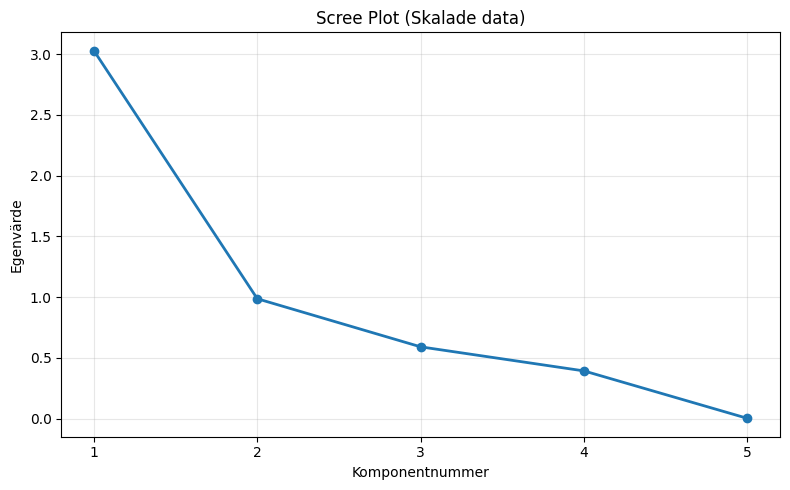

In [21]:
pca_full = PCA()
pca_full.fit(X_scaled)

eigenvalues = pca_full.explained_variance_

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(eigenvalues)+1),
    eigenvalues,
    marker="o",
    linewidth=2
)

plt.title("Scree Plot (Skalade data)")
plt.xlabel("Komponentnummer")
plt.ylabel("Egenvärde")
plt.xticks(range(1, len(eigenvalues)+1))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Förklarad varians och egenvärden per huvudkomponent

In [22]:
eigenvalues = pca_full.explained_variance_
explained_var = pca_full.explained_variance_ratio_

pca_table = pd.DataFrame({
    "Komponent": range(1, len(explained_var)+1),
    "Egenvärde": eigenvalues,
    "Förklarad varians (%)": explained_var * 100,
    "Kumulativ varians (%)": np.cumsum(explained_var) * 100
})

pca_table["Egenvärde"] = pca_table["Egenvärde"].round(3)
pca_table["Förklarad varians (%)"] = pca_table["Förklarad varians (%)"].round(2)
pca_table["Kumulativ varians (%)"] = pca_table["Kumulativ varians (%)"].round(2)

print("PCA sammanfattning:")
print(pca_table)

PCA sammanfattning:
   Komponent  Egenvärde  Förklarad varians (%)  Kumulativ varians (%)
0          1      3.027                  60.53                  60.53
1          2      0.987                  19.73                  80.26
2          3      0.591                  11.82                  92.08
3          4      0.393                   7.86                  99.94
4          5      0.003                   0.06                 100.00


## Variablernas bidrag till huvudkomponenterna

In [23]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f"PC{i}" for i in range(1, len(X.columns)+1)],
    index=X.columns
)

print("\nLoadingstabell:")
print(loadings.round(3))


Loadingstabell:
                  PC1    PC2    PC3    PC4    PC5
Recency        -0.351  0.526  0.775  0.020  0.013
Frequency       0.476 -0.346  0.469 -0.411 -0.515
Monetary        0.550  0.192  0.115 -0.319  0.739
AvgOrderValue   0.349  0.752 -0.343 -0.076 -0.434
UniqueProducts  0.476 -0.041  0.221  0.850 -0.011


## PCA Scatterplot
Figuren visar kunder projicerade på de två första huvudkomponenterna. Den största delen av kunderna återfinns i ett centralt och tätt område, vilket indikerar liknande köpbeteenden för majoriteten av kunderna. Samtidigt finns ett mindre antal avvikande observationer, vilket tyder på kunder med mer extrema beteendemönster, exempelvis högre köpfrekvens eller större ordervärden.

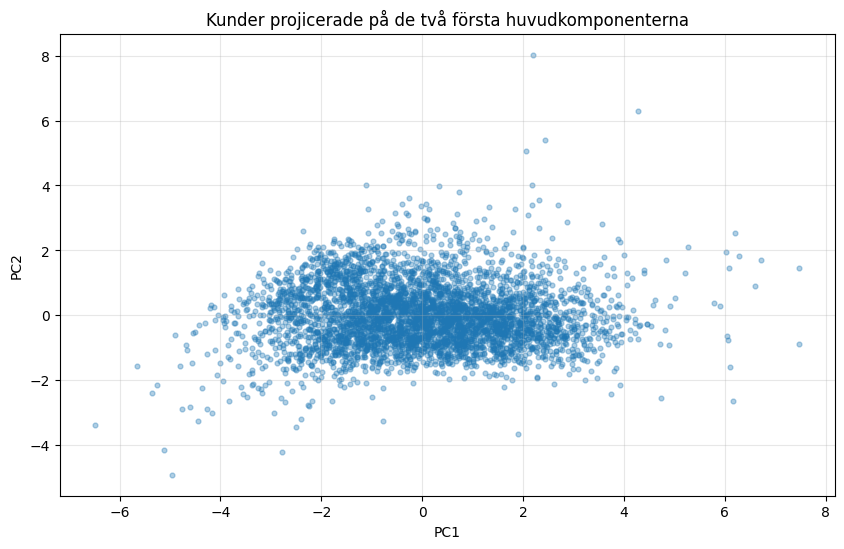

In [24]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.35, s=12)

plt.title("Kunder projicerade på de två första huvudkomponenterna")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)

plt.show()

## Heatmap

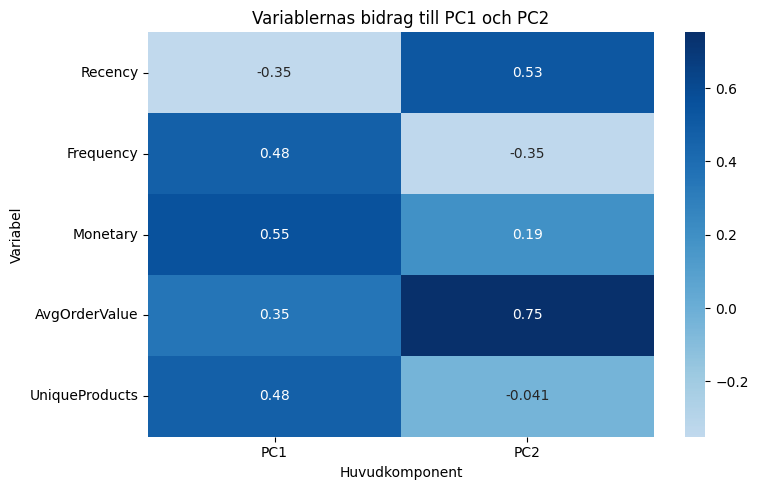

In [25]:
plt.figure(figsize=(8,5))
sns.heatmap(loadings[["PC1","PC2"]], annot=True, cmap="Blues", center=0)

plt.title("Variablernas bidrag till PC1 och PC2")
plt.xlabel("Huvudkomponent")
plt.ylabel("Variabel")
plt.tight_layout()
plt.show()

# 8. K-Means
K-Means användes för att segmentera kunder utifrån de skapade kundvariablerna: Recency, Frequency, Monetary, AvgOrderValue och UniqueProducts. Syftet var att identifiera grupper av kunder med liknande köpbeteenden.

Eftersom K-Means bygger på avstånd mellan observationer genomfördes klustringen på de standardiserade variablerna (X_scaled), så att ingen variabel skulle dominera analysen på grund av större skala.

## Val av antal kluster – Elbow-metoden
För att välja ett lämpligt antal kluster testades flera olika värden på k med hjälp av Elbow-metoden. Metoden mäter modellens inertia, vilket beskriver den totala variationen inom klustren. Lägre inertia innebär mer homogena kluster.

Diagrammet visar att inertia minskar kraftigt mellan k = 1 och k = 3, därefter avtar förbättringen successivt. Detta tyder på att ett rimligt antal kluster ligger omkring 3–4 kluster, där modellen fångar tydliga skillnader utan att bli onödigt komplex.

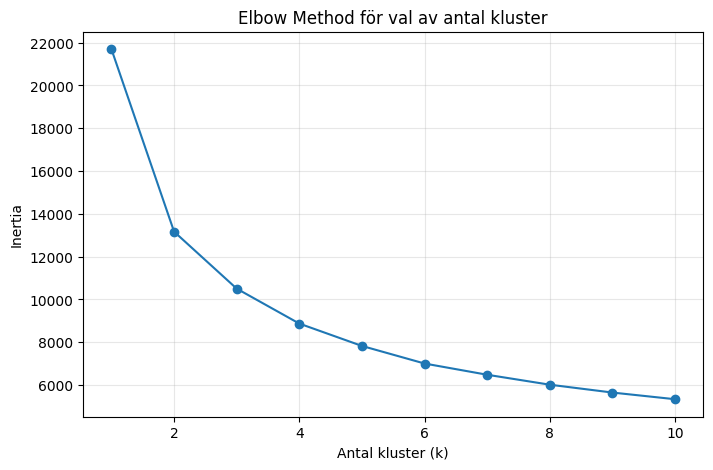

In [26]:
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker="o")

plt.title("Elbow Method för val av antal kluster")
plt.xlabel("Antal kluster (k)")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.show()

## Val av modell
Utifrån elbow-diagrammet valdes k = 4 för den fortsatta analysen. Detta bedömdes ge en god balans mellan tolkningsbarhet och förmåga att fånga olika kundsegment. Kurvan uppvisar ett tydligt knä kring 3–4 kluster, vilket indikerar att ytterligare kluster efter denna punkt endast ger begränsad förbättring i form av minskad inertia.

In [27]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_features["Cluster"] = kmeans.fit_predict(X_scaled)

## Klusteröversikt
För att analysera skillnader mellan de identifierade segmenten beräknades medelvärden för respektive variabel inom varje kluster. Detta gör det möjligt att jämföra kundgruppernas köpbeteenden och identifiera exempelvis mer lojala, högvärdiga eller lågaktiva kunder.

In [28]:
cluster_summary = customer_features.drop("CustomerID", axis=1).groupby("Cluster").mean().round(2)
print(cluster_summary)

         Recency  Frequency  Monetary  AvgOrderValue  UniqueProducts
Cluster                                                             
0          68.21       0.93      5.30           4.93            2.53
1          59.09       1.26      6.78           5.90            3.79
2          25.07       2.33      8.24           6.03            4.78
3         269.05       0.81      5.64           5.45            2.72


## Visualisering av kluster
För att tydligare illustrera segmenteringen visualiserades klustren i PCA-rummet med hjälp av de två första huvudkomponenterna.

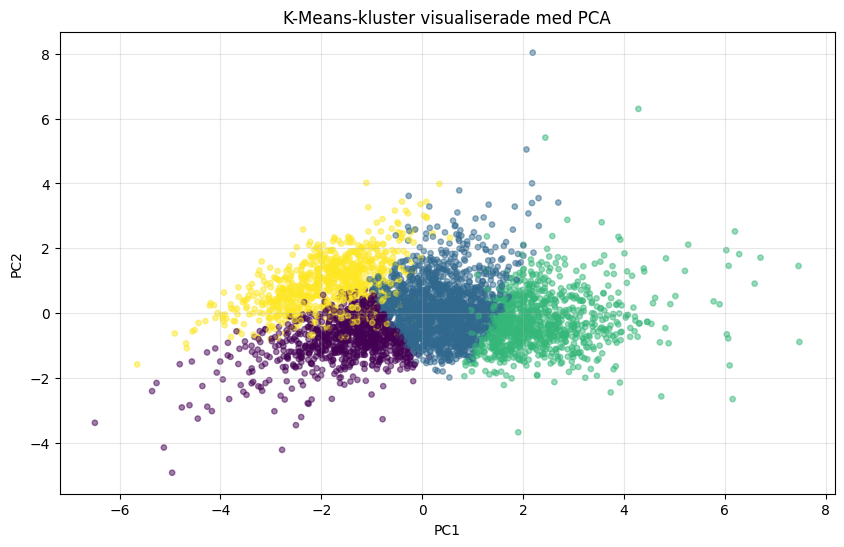

In [29]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=customer_features["Cluster"],
    cmap="viridis",
    alpha=0.5,
    s=15
)

plt.title("K-Means-kluster visualiserade med PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()

## Tolkning av kluster

Resultatet visar att kunderna kunde delas in i fyra tydliga segment med olika köpbeteenden. Klustren skiljer sig främst åt vad gäller aktualitet (Recency), köpfrekvens (Frequency) samt total omsättning (Monetary).

### Kluster 0 – Regelbundna kunder med lägre värde

Kunder i detta kluster har relativt låg köpfrekvens och lägre omsättning än genomsnittet, men har handlat relativt nyligen. Gruppen kan beskrivas som aktiva kunder med begränsad köpnivå.

### Kluster 1 – Stabila mellankunder

Detta kluster uppvisar något högre köpfrekvens, större omsättning och fler unika produkter än kluster 0. Gruppen representerar stabila kunder med återkommande köp.

### Kluster 2 – Högvärdeskunder

Kunder i detta kluster har lägst Recency (mest nyliga köp), högst köpfrekvens, högst omsättning samt flest unika produkter. Detta segment representerar företagets mest värdefulla och engagerade kunder.

### Kluster 3 – Inaktiva kunder

Detta kluster kännetecknas av mycket hög Recency, vilket innebär att kunderna inte har handlat på länge. Gruppen har även låg köpfrekvens och relativt låg omsättning. Dessa kunder kan betraktas som vilande eller förlorade kunder.

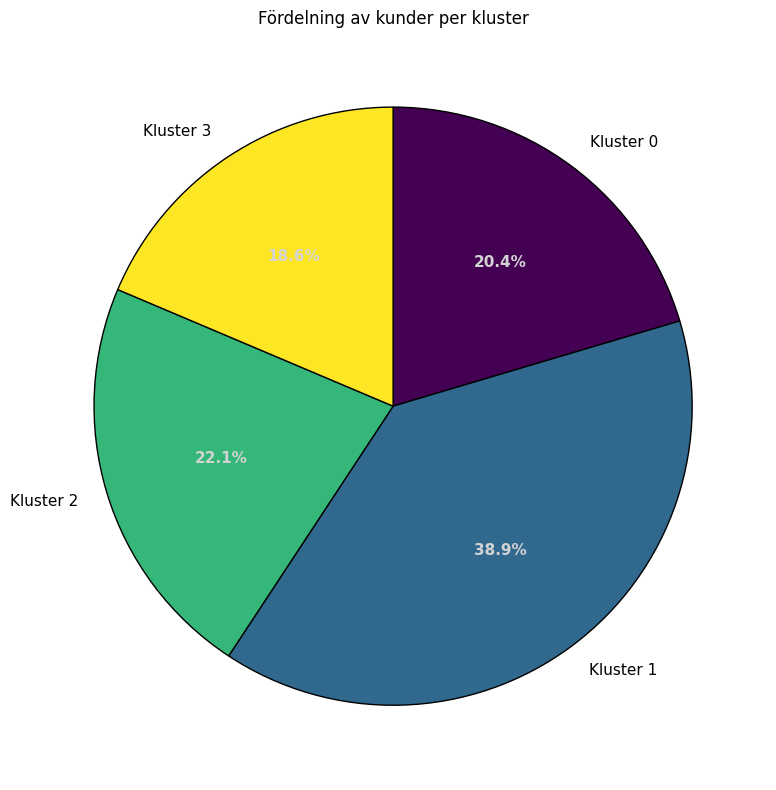

In [30]:
cluster_counts = customer_features["Cluster"].value_counts().sort_index()

colors = plt.cm.viridis(np.linspace(0, 1, 4))

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    cluster_counts,
    labels=[f"Kluster {i}" for i in cluster_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops={"edgecolor": "black"},
    textprops={"color": "black", "fontsize": 11}
)

# Percentage text inside slices
for autotext in autotexts:
    autotext.set_color("lightgray")
    autotext.set_fontsize(11)
    autotext.set_weight("bold")

plt.title("Fördelning av kunder per kluster")
plt.tight_layout()
plt.show()

# 9. DBSCAN
DBSCAN testades som alternativ klustringsmetod.

In [31]:
dbscan = DBSCAN(eps=0.8, min_samples=10)

customer_features["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)

print(customer_features["DBSCAN_Cluster"].value_counts().sort_index())

DBSCAN_Cluster
-1     175
 0    4163
Name: count, dtype: int64


## Resultat
DBSCAN identifierade ett huvudsakligt kluster med 4 163 kunder samt 175 avvikande observationer markerade som noise.

Det innebär att majoriteten av kunderna uppvisar relativt liknande köpbeteenden, medan en mindre grupp avviker tydligt från mängden.

## Visualisering av DBSCAN
Figuren visar resultatet från DBSCAN projicerat i PCA-rummet. Den största delen av kunderna återfinns i ett centralt och tätt område, vilket innebär att de tillhör det huvudsakliga klustret med liknande köpbeteenden. Ett mindre antal observationer ligger längre från huvudmassan och klassificeras därför som avvikande kunder (noise).

Detta tyder på att majoriteten av kundbasen är relativt homogen, medan en mindre grupp kunder uppvisar mer ovanliga beteendemönster. Dessa kunder kan exempelvis ha mycket hög omsättning, ovanligt hög köpfrekvens eller lång tid sedan senaste köp.

Jämfört med K-Means, som delade upp samtliga kunder i fyra segment, fokuserar DBSCAN i stället på att identifiera täta grupper samt observationer som avviker från mängden. Metoden bidrar därför främst med ytterligare förståelse för extrema eller atypiska kunder.

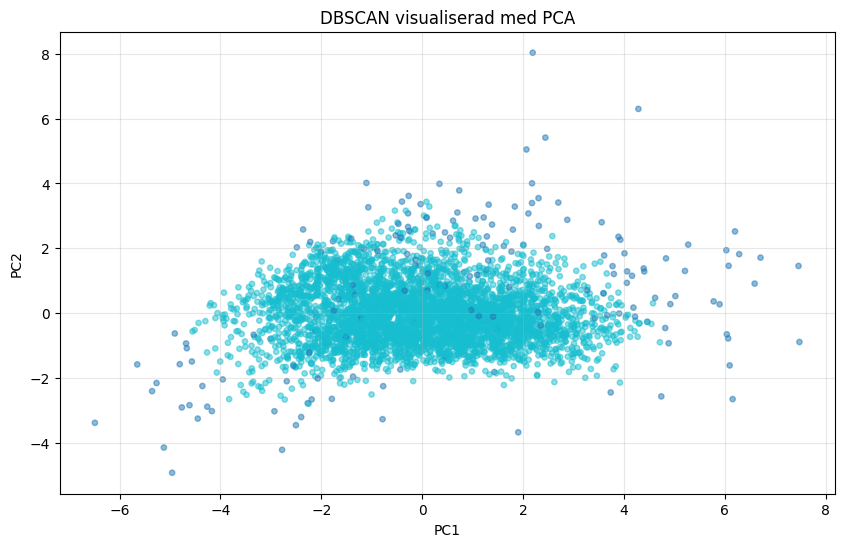

In [32]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=customer_features["DBSCAN_Cluster"],
    cmap="tab10",
    alpha=0.5,
    s=15
)

plt.title("DBSCAN visualiserad med PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()

# 10. Resultat
Analysen visade att det var möjligt att identifiera tydliga mönster i kunddatan genom explorativ dataanalys, feature engineering, PCA och K-Means-klustring.

## EDA
EDA visade att försäljningen var starkt koncentrerad till Storbritannien, vilket stod för den största delen av den totala omsättningen. Försäljningen uppvisade även tydliga säsongsvariationer, där högre omsättning noterades under hösten och särskilt inför november, medan december endast innehöll delar av månaden.

Kundbeteendet var tydligt högerskevt. Majoriteten av kunderna genomförde få köp, medan ett mindre antal kunder stod för betydligt fler ordrar och högre omsättning. Detta indikerar att vissa kunder har ett betydligt högre affärsvärde än genomsnittet.

## PCA
Genom PCA reducerades kundvariablerna till två huvudkomponenter som tillsammans förklarade en stor del av variationen i datan. Detta möjliggjorde visualisering av kundstrukturen och underlättade den fortsatta segmenteringen.

## K-Means-klustringen
K-Means-klustringen identifierade fyra huvudsakliga kundsegment:

- **Kluster 0**: Regelbundna kunder med lägre värde
- **Kluster 1**: Stabila mellankunder
- **Kluster 2**: Högvärdeskunder
- **Kluster 3**: Inaktiva kunder

Segmenteringen visar att kundbasen består av både lojala högvärdeskunder och kunder med låg aktivitet, vilket skapar goda möjligheter för riktade affärsinsatser.

## Storlek på kluster
För att förstå hur kundbasen fördelar sig mellan segmenten analyserades antalet kunder i varje kluster.

Resultatet visar att klustren var relativt jämnt fördelade, men med vissa skillnader i storlek.

- **Kluster 1** var störst med 1 686 kunder (cirka 39 % av kundbasen).
- **Kluster 2** innehöll 959 kunder (cirka 22 %).
- **Kluster 0** bestod av 885 kunder (cirka 20 %).
- **Kluster 3** var minst med 808 kunder (cirka 19 %).

Detta innebär att majoriteten av kunderna återfanns i mellansegmentet (Kluster 1), medan högvärdes- och inaktiva kunder utgjorde mindre men strategiskt viktiga grupper.

In [33]:
customer_features["Cluster"].value_counts().sort_index()

Cluster
0     885
1    1686
2     959
3     808
Name: count, dtype: int64

# 11. Slutsats
Syftet med projektet var att analysera kunddata och identifiera meningsfulla kundsegment med hjälp av dataminingmetoder. Resultatet visar att kombinationen av feature engineering, PCA och K-Means var väl lämpad för uppgiften.

Analysen visade tydligt att kunder skiljer sig åt i köpbeteende vad gäller aktualitet, köpfrekvens och omsättning. Särskilt viktigt var identifieringen av ett högvärdessegment med frekventa och nyliga köp, samt ett inaktivt segment med hög risk att ha lämnat företaget.

Resultatet kan användas praktiskt inom exempelvis CRM, marknadsföring och kundlojalitetsarbete. Företaget kan rikta erbjudanden till högvärdeskunder, återaktivera vilande kunder och anpassa kommunikation till olika segment.

Sammanfattningsvis visar projektet hur osuperviserad maskininlärning kan användas för att skapa affärsvärde genom bättre förståelse av kundbasen.